# 04 — Product Analysis: Segments, Routing, Cold Start, and the A/B Test

`03_models.ipynb` answered "which model has the best offline ranking
metric". This notebook asks the product question: **for which users does
which strategy actually work, what would we ship, and how would we check
it in production?**

**Test-set discipline** (same principle as `02`/`03`): the routing policy
below is chosen entirely from validation results (Sections 2–4), then
**frozen** before any test-set segment result is computed or displayed
(Section 5). Test is used only to check the already-frozen policy, never to
pick it.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from src import data as D
from src import evaluation as E
from src import pipeline as P

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
FIG_DIR = "../reports/figures"
TABLE_DIR = "../reports/tables"
K = P.K

## 1. Rebuild validation and test recommendations

In [2]:
users, movies, df, user_id_to_idx, item_id_to_idx = P.load_and_split("../data")
n_users = df["user_idx"].nunique()

# validation-phase models (train only) -- used to choose the routing strategy
fitted_val = P.fit_all_models(df, movies, item_id_to_idx, ["train"])
seen_val = D.get_seen(df, ["train"])
raw_truth_val = D.get_truth(df, "val", threshold=D.RELEVANT_RATING_THRESHOLD)
truth_val, truth_val_stats = D.restrict_truth_to_catalog(raw_truth_val, fitted_val["item_pos"])
users_val = list(truth_val.keys())
rec_val = P.recommend_all(fitted_val, users_val, seen_val, K)

# test-phase models (train+val) -- used only for the final, frozen-policy check
fitted_test = P.fit_all_models(df, movies, item_id_to_idx, ["train", "val"])
seen_test = D.get_seen(df, ["train", "val"])
raw_truth_test = D.get_truth(df, "test", threshold=D.RELEVANT_RATING_THRESHOLD)
truth_test, truth_test_stats = D.restrict_truth_to_catalog(raw_truth_test, fitted_test["item_pos"])
users_test = list(truth_test.keys())
rec_test = P.recommend_all(fitted_test, users_test, seen_test, K)

print(f"Validation: {truth_val_stats['excluded_not_in_catalog']} relevant interactions "
      f"({truth_val_stats['excluded_share']:.2%}) excluded as not-yet-in-catalog.")
print(f"Test:       {truth_test_stats['excluded_not_in_catalog']} relevant interactions "
      f"({truth_test_stats['excluded_share']:.2%}) excluded as not-yet-in-catalog.")
print("(Ranking metrics below use the catalog-restricted 'recommendable' truth, "
      "consistent with 02/03 -- see 02_evaluation_setup.ipynb Section 2.)")

Validation: 12 relevant interactions (0.01%) excluded as not-yet-in-catalog.
Test:       13 relevant interactions (0.02%) excluded as not-yet-in-catalog.
(Ranking metrics below use the catalog-restricted 'recommendable' truth, consistent with 02/03 -- see 02_evaluation_setup.ipynb Section 2.)


## 2. User-history segments

`01_data_and_eda.ipynb` showed MovieLens-1M has essentially no *absolute*
cold-start users (everyone has 20+ ratings) but a heavy-tailed activity
distribution. Segments are defined by **quartiles of each user's history
size at the moment of prediction** — i.e. a *relative*, pre-outcome
covariate (how many interactions a user has logged so far), not an outcome
of any model. Concretely: train-interaction counts for the validation
phase, train+val-interaction counts for the test phase, with quartile cut
points **recomputed separately for each phase** from that phase's own
distribution, so a "sparse (Q1)" user always means "bottom 25% of users by
history size at that point in time", never a fixed absolute count.

In [3]:
train_counts = df[df.split == "train"].groupby("user_idx").size().to_dict()
trainval_counts = df[df.split.isin(["train", "val"])].groupby("user_idx").size().to_dict()

edges_val = np.quantile(list(train_counts.values()), [0.25, 0.5, 0.75])
edges_test = np.quantile(list(trainval_counts.values()), [0.25, 0.5, 0.75])
labels = ["sparse (Q1)", "low (Q2)", "medium (Q3)", "high (Q4)"]
print("Validation-phase cutoffs (train interactions):", edges_val)
print("Test-phase cutoffs (train+val interactions):   ", edges_test)

seg_val = E.segment_of_users(train_counts, edges_val, labels)
seg_test = E.segment_of_users(trainval_counts, edges_test, labels)

Validation-phase cutoffs (train interactions): [ 31.  67. 146.]
Test-phase cutoffs (train+val interactions):    [ 37.  82. 177.]


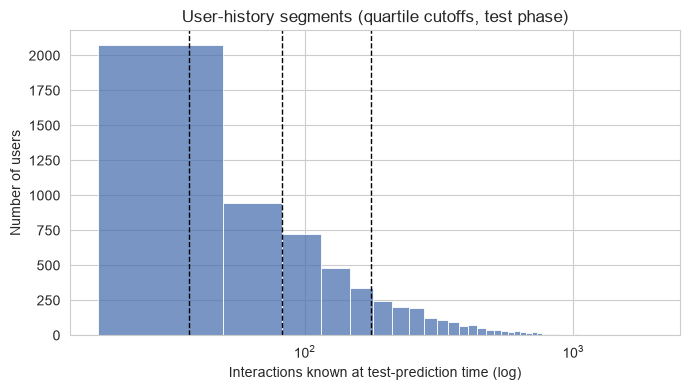

In [4]:
plt.figure(figsize=(7, 4))
sns.histplot(list(trainval_counts.values()), bins=60, color="#4C72B0")
for e in edges_test:
    plt.axvline(e, color="black", linestyle="--", linewidth=1)
plt.xscale("log")
plt.xlabel("Interactions known at test-prediction time (log)")
plt.ylabel("Number of users")
plt.title("User-history segments (quartile cutoffs, test phase)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/segment_cutoffs.png", dpi=150)
plt.show()

## 3. Model quality by segment — VALIDATION (this is what drives the routing decision)

In [5]:
seg_table_val = pd.DataFrame(E.segment_metrics_table(rec_val, truth_val, seg_val, K))
seg_table_val.to_csv(f"{TABLE_DIR}/segment_metrics_val.csv", index=False)

pivot_val = seg_table_val.pivot(index="model", columns="segment", values="NDCG@K")[labels]
pivot_val.round(4)

segment,sparse (Q1),low (Q2),medium (Q3),high (Q4)
model,,,,
ALS,0.1137,0.0867,0.0814,0.1176
BPR,0.1016,0.0723,0.0615,0.0785
Content-Based,0.0180,0.0146,0.0167,0.0195
Hybrid,0.1162,0.0976,0.0922,0.1407
Item-kNN,0.1090,0.0921,0.0937,0.1503
Popularity,0.0402,0.0514,0.0695,0.1416


**Per-segment validation winners:** Hybrid wins sparse (0.116) and low
(0.098); Item-kNN wins medium (0.094) and high (0.150). Popularity is a
close **second** in high (0.142) — ahead of Hybrid (0.141) there, its best
showing relative to the leader in any segment. ALS does not win any segment
on validation, despite becoming the strongest model overall on test
(Section 5) — a first sign that segment-level NDCG, computed over
~1,450–1,500 users per segment, is noisy enough that "best on this
validation slice" does not reliably predict "best on test" once the
difference between candidates is small.

## 4. Freeze the routing policy (validation only)

In [6]:
router = E.build_router(rec_val, truth_val, seg_val, K)
print("Routing policy, chosen on VALIDATION NDCG@10 and FROZEN from this point on:")
for seg in labels:
    print(f"  {seg:12s} -> {router.get(seg)}")

Routing policy, chosen on VALIDATION NDCG@10 and FROZEN from this point on:
  sparse (Q1)  -> Hybrid
  low (Q2)     -> Hybrid
  medium (Q3)  -> Item-kNN
  high (Q4)    -> Item-kNN


The frozen policy: **sparse → Hybrid, low → Hybrid, medium → Item-kNN,
high → Item-kNN**. Nothing below this point can change it.

## 5. Apply the frozen policy to test

Only now is any test-set segment result computed or shown — the policy
above was already fixed using validation alone.

In [7]:
seg_table_test = pd.DataFrame(E.segment_metrics_table(rec_test, truth_test, seg_test, K))
seg_table_test.to_csv(f"{TABLE_DIR}/segment_metrics_test.csv", index=False)

pivot_test = seg_table_test.pivot(index="model", columns="segment", values="NDCG@K")[labels]
pivot_test.round(4)

segment,sparse (Q1),low (Q2),medium (Q3),high (Q4)
model,,,,
ALS,0.1048,0.0827,0.0845,0.1511
BPR,0.0845,0.0637,0.0647,0.0937
Content-Based,0.0175,0.0162,0.0150,0.0194
Hybrid,0.0938,0.0861,0.0792,0.1505
Item-kNN,0.0920,0.0857,0.0823,0.1558
Popularity,0.0359,0.0465,0.0700,0.1420


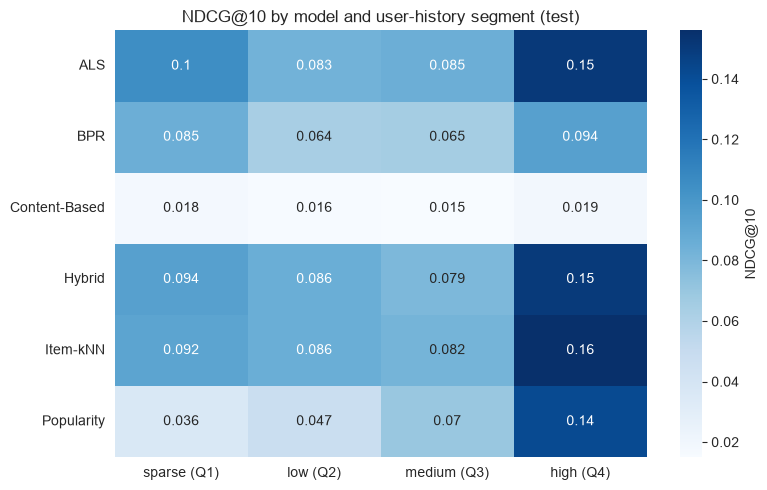

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_test.round(3), annot=True, cmap="Blues", cbar_kws={"label": "NDCG@10"})
plt.title("NDCG@10 by model and user-history segment (test)")
plt.ylabel(""); plt.xlabel("")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/segment_heatmap.png", dpi=150)
plt.show()

**The test-time per-segment winners are not the same as the validation-time
winners the policy was frozen on:** on test, ALS actually wins the sparse
(0.105) and medium (0.085) segments, and is within noise of the winner in
the other two — none of which validation predicted (Section 3). This is
the segment-level result of the same instability flagged above: with
~1,450–1,500 users per segment, "best on validation" and "best on test"
diverge more often than the routing logic assumes, even though the policy
itself was chosen honestly, without ever looking at test.

In [9]:
routed_test = E.apply_router(router, rec_test, seg_test, users_test)
router_metrics = E.full_evaluation(
    routed_test, truth_test, fitted_test["catalog_items"], fitted_test["pop_count"],
    fitted_test["n_train_interactions"], fitted_test["feature_matrix"], fitted_test["item_pos"], K,
)

comparison = pd.DataFrame(P.evaluate_all(rec_test, truth_test, fitted_test, K)).set_index("model")
comparison.loc["Routing strategy"] = router_metrics
comparison = comparison.drop(columns=[c for c in comparison.columns if c == "n_users"])
comparison.sort_values("NDCG@K", ascending=False).round(4)

,Recall@K,Precision@K,MAP@K,NDCG@K,Coverage@K,Novelty@K,Diversity@K,AvgPopularity@K
model,,,,,,,,
ALS,0.0898,0.0808,0.0521,0.1059,0.2983,9.5929,0.6183,1287.9264
Routing strategy,0.0837,0.0801,0.0514,0.1047,0.1382,8.9869,0.6083,1791.2226
Item-kNN,0.0820,0.0795,0.0514,0.1042,0.1265,8.9360,0.6347,1846.9774
Hybrid,0.0830,0.0785,0.0500,0.1026,0.1436,9.0428,0.5810,1734.1050
BPR,0.0707,0.0558,0.0352,0.0767,0.6448,11.0976,0.4799,604.4369
Popularity,0.0477,0.0623,0.0349,0.0740,0.0362,8.4986,0.6451,2378.5328
Content-Based,0.0169,0.0130,0.0069,0.0170,0.8325,13.1369,0.0851,258.7841


**The routing strategy no longer leads the comparison.** With the
representation choice from `02_evaluation_setup.ipynb` Section 4.7 applied,
**ALS is the single best model on test on every ranking metric shown**
(Recall/Precision/MAP/NDCG@10), and it also has **higher catalog coverage
(0.298) than the routing strategy (0.138), Item-kNN (0.127) or the Hybrid
(0.144)**. The router, built honestly from validation without ever looking
at test, still lands a respectable second place overall — but it is no
longer the best offline result in the project, and it does not beat plain
ALS on either accuracy or coverage here. Section 6 quantifies how much
weight the accuracy gap can actually bear.

In [10]:
import json
with open(f"{TABLE_DIR}/router_summary.json", "w") as f:
    json.dump({
        "router": router,
        "router_test_metrics": router_metrics,
        "edges_val": edges_val.tolist(),
        "edges_test": edges_test.tolist(),
    }, f, indent=2, default=float)
print("saved")

saved


## 6. How much confidence do we actually have in the routing gain?

The routing strategy's NDCG@10 is close to, and (Section 5) not even ahead
of, the single best model. A paired user-level bootstrap (resampling users
with replacement, 10,000 resamples; see
`src/evaluation.py::paired_bootstrap_ci`) quantifies that uncertainty
directly on the same test cohort and truth used above, for both the
comparison this project treats as the default reference point (Router vs.
Item-kNN, the simplest strong model) and the comparison against the model
that actually tops the table now (Router vs. ALS).

In [11]:
comparisons = {
    "Routing strategy vs Item-kNN": E.paired_bootstrap_ci(routed_test, rec_test["Item-kNN"], truth_test, K),
    "Hybrid vs Item-kNN": E.paired_bootstrap_ci(rec_test["Hybrid"], rec_test["Item-kNN"], truth_test, K),
    "Routing strategy vs ALS": E.paired_bootstrap_ci(routed_test, rec_test["ALS"], truth_test, K),
}
for label, res in comparisons.items():
    print(f"{label} (NDCG@10):")
    print(f"  observed delta = {res['observed_delta']:+.5f}")
    print(f"  95% CI = [{res['ci_low']:+.5f}, {res['ci_high']:+.5f}]  (includes zero: {res['ci_includes_zero']})")
    print()

Routing strategy vs Item-kNN (NDCG@10):
  observed delta = +0.00054
  95% CI = [-0.00044, +0.00153]  (includes zero: True)

Hybrid vs Item-kNN (NDCG@10):
  observed delta = -0.00157
  95% CI = [-0.00296, -0.00017]  (includes zero: False)

Routing strategy vs ALS (NDCG@10):
  observed delta = -0.00120
  95% CI = [-0.00501, +0.00263]  (includes zero: True)



**The routing strategy's deltas are not distinguishable from zero; the
Hybrid's is.** Routing strategy vs. Item-kNN is a small positive point
estimate (+0.0005) with a 95% CI of `[-0.0004, +0.0015]` — includes zero,
so not distinguishable from no effect. Routing strategy vs. ALS is a small
negative point estimate (-0.0012) with CI `[-0.0050, +0.0026]` — also not
distinguishable from zero. **Hybrid vs. Item-kNN is the one comparison
where the CI excludes zero** (`[-0.0030, -0.0002]`): despite the two
models' point estimates looking close in the main table (0.1026 vs.
0.1042), the *paired*, per-user bootstrap has enough power to detect that
the Hybrid is consistently, if only slightly, behind Item-kNN across users
— a reminder that a paired comparison on the same users can resolve a
difference that looks like noise when only looking at two aggregate
numbers.

Net reading: **no offline evidence that the router beats a good single
model** — not "the router is better" and not "the router is worse", just
genuinely uncertain at this sample size — while the Hybrid has a small but
real accuracy cost relative to the plain Item-kNN it is built on. This
directly shapes the product decision below.

## 7. Cold start

**User cold start.** MovieLens-1M is pre-filtered to users with 20+ ratings
(`01_data_and_eda.ipynb`), so genuine new-user cold start (0 interactions)
cannot be observed or evaluated in this dataset — every "sparse" user here
still has at least 14 training interactions. In a real product, a
brand-new user has none of that, and none of the models compared here would
have anything to rank on: Item-kNN, ALS, BPR and the Hybrid all require at
least one training interaction. The only strategies usable at true
zero-history are **Popularity** and an onboarding flow (asking for a few
genre/title preferences up front, which is exactly what would let a
**Content-Based** score be computed from interaction zero). This project's
segment analysis therefore describes "users with less history than
others", not "brand-new users" — a real limitation of using MovieLens-1M
for this question.

**Item cold start.** This is directly observable and now quantified twice:
qualitatively in `01_data_and_eda.ipynb` (~7.8% of rated movies have fewer
than 5 ratings, 177 catalog movies have never been rated at all), and
directly in the ranking evaluation itself (Section 1 above and
`02_evaluation_setup.ipynb` Section 2, `03_models.ipynb` Section 1): a small
but non-zero share of relevant validation/test interactions belong to
items that were not yet in the candidate catalog and so could not have been
recommended by any model. Collaborative and factorization models (Item-kNN,
ALS, BPR) cannot recommend an item with no interaction history at all;
Content-Based is the only model in this comparison that can score a new
item on day one, from its genres and release year alone.

**Production implication:** a real system would not pick one model for
everyone — it would route new users to popularity/onboarding-content, keep
new items visible via a content-based or explicit "new releases" slot, and
let the collaborative/hybrid models take over once enough interaction data
exists. This is the same logic behind the segment-based routing strategy
above, extended to the boundary case Q1 doesn't actually cover (zero
history), which is not observable in this dataset.

## 8. Product decision

Based only on what was actually measured above:

1. **Default model: ship ALS.** After the representation fix in
   `02_evaluation_setup.ipynb` Section 4.7, ALS is the single best model on
   test on every ranking metric (NDCG@10 = 0.106) *and* has meaningfully
   higher catalog coverage (0.30) than Item-kNN (0.13) or the Hybrid (0.14).
   Item-kNN remains a reasonable, simpler fallback (no factorization
   training, trivially explainable as "people who liked what you liked also
   liked...") a close third at NDCG@10 = 0.104.
2. **Do not build the routing infrastructure on this evidence, and do not
   ship the Hybrid either.** The segment-based router was a legitimate,
   validation-only result and looked like the best strategy in the project
   before this cleanup pass — but Section 6's bootstrap shows its offline
   edge (over Item-kNN, and its shortfall against ALS) is not
   distinguishable from zero. Recommending four production models plus a
   routing layer on a delta this uncertain would be adding real engineering
   and monitoring cost for an unproven gain. The Hybrid is worse: the same
   bootstrap shows it is measurably (if only slightly) *behind* the plain
   Item-kNN it is built on, a CI that does not include zero — so it is not
   a candidate default either. This is a direct instance of the earlier,
   over-confident version of this same analysis: a small offline delta was
   reported as "the router beats every model" before uncertainty was
   actually quantified.
3. **Keep Popularity as a zero-data fallback, not a segment winner.**
   Popularity never wins a segment on validation, though in the
   high-history segment it edges out the Hybrid (0.142 vs. 0.141) while
   still trailing the segment leader, Item-kNN (0.150) — it remains
   valuable mainly because it needs no trained model and no user history
   at all.
4. **Content-Based leads coverage and novelty, not accuracy — a deliberate
   trade a product team could make, not a general replacement.** ALS
   (the accuracy leader) reaches under a third of the catalog (Coverage@10 =
   0.30) and leans on already-popular items (avg. recommended popularity ≈
   1,290 interactions); Content-Based reaches 83% of the catalog and the
   least popular items on average (avg. recommended popularity ≈ 260), at
   the cost of much lower ranking accuracy (NDCG@10 = 0.017). If catalog
   health / long-tail exposure matters as a product goal, blending in 1–2
   higher-novelty slots from Content-Based is a deliberate,
   measurable accuracy-for-diversity trade — this project does not have the
   data to say users would tolerate it.
5. **What this offline analysis cannot tell us:** whether switching from
   today's baseline to ALS changes actual engagement, and whether the
   router's small, uncertain offline edge would show up (or reverse) online.
   Offline Recall/NDCG measure whether a model *would have* ranked a movie
   the user *happened to rate ≥4 later* near the top — not whether showing
   it changes what the user does. That gap is exactly what Section 9's A/B
   test is designed to close, and the router's uncertainty (Section 6) is
   itself part of why an online read matters here.

## 9. A/B test design: baseline → ALS

This is a **design**, not a simulated result. MovieLens has no CTR or
watch-time data, so no real baseline conversion rate exists to plug in —
the sample-size table below is an explicit **sensitivity/scenario
analysis**, not a forecast.

Section 8 recommends **ALS** as the model to ship, not the segment router —
the router's offline edge was not distinguishable from zero (Section 6).
The test below is therefore designed around the recommendation that
survived that check: today's baseline model vs. ALS. If a team wanted to
test the router anyway (e.g. because per-segment behavior matters for
reasons beyond aggregate NDCG), the same design applies with the router as
the treatment arm instead — the primary/secondary/guardrail metrics and
sample-size logic do not change.

**Hypothesis.** Switching the default recommendation model to ALS
increases engagement with recommended movies compared to today's baseline
policy, without degrading recommendation latency or over-concentrating
recommendations on a handful of titles.

**Randomization unit.** User (not session or impression) — recommendation
quality compounds across a user's sessions, and per-user randomization
avoids a single user seeing both arms.

**Control.** The current production recommendation policy (whatever model
is deployed today).

**Treatment.** ALS-based recommendations, served to every user (Section 8).

**Primary metric.** *Recommendation click-through rate* — clicks (or
play-starts) on a recommended movie divided by recommendation impressions.
It is the direct, short-latency behavioral analogue of the offline ranking
metrics (Recall/NDCG) used in this project, and is standard for a
recommendation-surface test.

**Secondary metrics.**
- Play-through / completion rate of clicked recommendations (does the click convert into real engagement, not just a curiosity click).
- Watch time attributable to recommended titles.
- Save / add-to-list rate on recommended titles.

**Guardrail metrics.**
- Recommendation-serving latency (p50/p95) — ALS scoring is a factor-vector dot product, cheap at inference, but the model must be retrained/refreshed on a schedule; watch for staleness as well as latency.
- Catalog concentration of what is actually shown (e.g. share of impressions going to the top 100 titles) — ALS's offline catalog coverage (0.30) is better than Item-kNN's (0.13) but still far from Content-Based's (0.83); this guardrail should catch further concentration in production.
- Overall session length / bounce rate — a guard against a regression in the broader experience, not just the recommendation module.

**Sample size / MDE sensitivity analysis.** Two-sided two-proportion z-test,
80% power, α=0.05, on primary-metric CTR. Required users **per arm** for a
few illustrative baseline CTR and relative-MDE combinations:

In [12]:
def required_n_per_arm(p1, relative_mde, alpha=0.05, power=0.80):
    p2 = p1 * (1 + relative_mde)
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    pooled = (p1 + p2) / 2
    numerator = (z_alpha * np.sqrt(2 * pooled * (1 - pooled)) + z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2))) ** 2
    return numerator / (p2 - p1) ** 2

rows = []
for p1 in [0.05, 0.10, 0.15]:
    for mde in [0.05, 0.10, 0.20]:
        n = required_n_per_arm(p1, mde)
        rows.append({"baseline_CTR": p1, "relative_MDE": mde, "target_CTR": round(p1 * (1 + mde), 4),
                     "users_per_arm": int(np.ceil(n))})
sensitivity = pd.DataFrame(rows)
sensitivity

,baseline_CTR,relative_MDE,target_CTR,users_per_arm
0,0.05,0.05,0.0525,122124
1,0.05,0.10,0.0550,31234
2,0.05,0.20,0.0600,8158
3,0.10,0.05,0.1050,57763
4,0.10,0.10,0.1100,14751
5,0.10,0.20,0.1200,3841
6,0.15,0.05,0.1575,36310
7,0.15,0.10,0.1650,9257
8,0.15,0.20,0.1800,2402


Reading this as a scenario table, not a forecast: detecting a **5% relative**
lift on a 10% baseline CTR needs roughly 58,000 users per arm; a **20%
relative** lift on the same baseline needs roughly 3,800 per arm. The real
required sample size depends entirely on the platform's actual baseline
CTR and traffic, which this project does not have access to — a real
rollout would plug in the platform's measured baseline before committing to
a test duration.

**Rollout suggestion.** Start on a small traffic slice (e.g. 5–10%) split
evenly control/treatment, run for at least one full weekly cycle (the EDA
in `01_data_and_eda.ipynb` found clear day-of-week/hour-of-day activity
patterns), monitor guardrails daily, and only ramp treatment traffic after
the primary metric is read at the pre-registered sample size — not before.

## 10. Limitations

- **No true user cold start is observable** in MovieLens-1M (Section 7); the "sparse" segment is relatively, not absolutely, low-history.
- **Item cold start is small but real and now quantified directly** (Section 1, and `02`/`03`): a small share of relevant validation/test interactions are structurally unrecommendable because the item had not yet appeared in the candidate catalog.
- **Genres + release year are the only item features used.** Richer metadata (cast, crew, synopsis/text embeddings, tags) was out of scope for this project and would likely help the content-based and hybrid models specifically.
- **Explicit ratings, not implicit behavior**, are the underlying signal. A real product observes clicks/plays/skips, which are noisier but far more abundant than a 1-5 star rating; the relevance definition (`rating >= 4`) and the confidence-weighting used for ALS/BPR (`02_evaluation_setup.ipynb`) are reasonable adaptations, not a substitute for validating against real implicit feedback.
- **LightFM was not used** (build failure on this environment, `02_evaluation_setup.ipynb`); BPR is a reasonable but not identical substitute, and does not consume genre features directly the way a LightFM hybrid would.
- **Offline ranking metrics are not a causal engagement estimate.** Everything in Sections 1–8 measures whether a model *would have* ranked a movie the user *happened* to rate later — not whether recommending it changes user behavior. Section 9 exists specifically because that gap can only be closed online.
- **The routing strategy does not have a demonstrated offline advantage.** Section 6's paired bootstrap shows its deltas vs. Item-kNN and vs. ALS are both within a 95% CI that includes zero — it is not shown to be better, and it is not shown to be worse; Section 8 recommends against building it on this evidence.
- **Segment-level metrics are noisy at this sample size** (~1,450–1,500 users per segment): the model that wins a segment on validation is not reliably the model that wins the same segment on test (Section 5), which is itself part of why the router's aggregate advantage did not hold up.